In [1]:
import os

from utils import run_proteus

import torch
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from scipy.stats.qmc import Halton

import numpy as np
import pandas as pd

from botorch.acquisition import ExpectedImprovement, UpperConfidenceBound

from botorch.optim import optimize_acqf

import matplotlib.pyplot as plt

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
dtype = torch.double

print(os.getcwd())
os.chdir("..")
print(os.getcwd())

/Users/benriegler/Documents/BO_Lichtenberg/PROTEUS/play_dummy
/Users/benriegler/Documents/BO_Lichtenberg/PROTEUS


In [2]:
data_path = "play_dummy/synth_data/struct.corefrac.csv"

# pick the ones that vary
obs = pd.read_csv(data_path, delimiter= "\t")[["contrast_ratio",
                                               "M_planet",
                                               "R_int",
                                               "transit_depth"]]

param = pd.read_csv(data_path, delimiter= "\t")[["index"]]



obs_mean = obs.mean(0)
obs_std = obs.std(0)

param_max = param.max(0)
param_min = param.min(0)

norm_param = (param - param_min) / (param_max - param_min)

std_obs = (obs - obs_mean) / obs_std

# to torch
param_min = torch.tensor(param_min.values)
param_max = torch.tensor(param_max.values)
obs_mean = torch.tensor(obs_mean.values)
obs_std = torch.tensor(obs_std.values)
std_obs = torch.tensor(std_obs.values)
norm_param = torch.tensor(norm_param.values)

#std_obs, norm_param

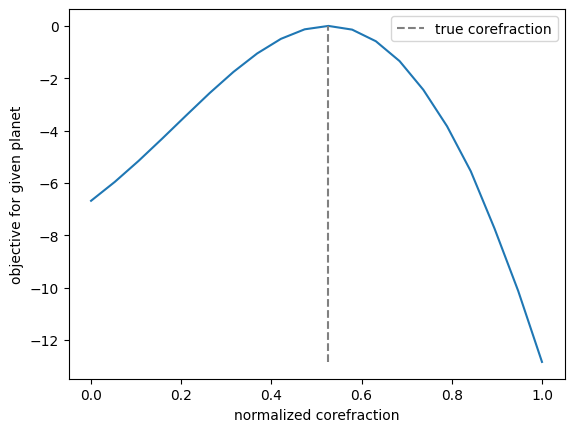

In [3]:
# choose planet from synthetic data

y = std_obs[10,:]; x = norm_param[10,:]

# calculate discretized objective

f = -((std_obs-y)**2).sum(1)

# plot objective over normalized input

plt.plot(norm_param, f)
plt.vlines(x,f.min(), f.max(), color = "grey", linestyles= "--", label="true corefraction")

plt.xlabel("normalized corefraction")
plt.ylabel("objective for given planet")

plt.legend()

plt.show()

In [4]:
def J(x):
    # change only the corefrac and keep rest fixed at dummy config/ at config of synthetic DGP

    # the observables of interest here
    observables = [ "contrast_ratio",
                    "M_planet",
                    "R_int",
                    "transit_depth"]

    run_name = "BO/simple_BO"

    # unnormalize input
    x = x*(param_max - param_min) +  param_min

    # un-torch
    x = x.item()

    par = {"struct.corefrac": x}

    sim = run_proteus(par, run_name, observables)

    # output to torch
    sim = torch.tensor(sim.values)
    sim = (sim - obs_mean) / obs_std
    J = ((y-sim)**2).sum().reshape(1,1)

    # BO Torch maximizes
    return -J, sim

In [5]:
# the optimium
J(x)[0]

tensor([[-0.]], dtype=torch.float64)

In [6]:
bounds = torch.tensor([[0.0], [1.0]], device=device, dtype=dtype)

BATCH_SIZE = 1
NUM_RESTARTS = 10
RAW_SAMPLES = 50


def optimize_acqf_and_get_observation(acq_func):
    """Optimizes the acquisition function, and returns a new candidate and a noisy observation."""
    # optimize

    candidates, _ = optimize_acqf(
        acq_function=acq_func,
        bounds=bounds,
        q=BATCH_SIZE,
        num_restarts=NUM_RESTARTS,
        raw_samples=RAW_SAMPLES,  # used for intialization heuristic
        options={"batch_limit": 5, "maxiter": 200},
    )
    # observe new values
    new_x = candidates.detach()
    new_y = J(new_x)[0]

    return new_x, new_y

def init_model(train_X, train_Y):

    gp = SingleTaskGP(
    train_X=train_X,
    train_Y=train_Y,
    input_transform=Normalize(d=1),
    outcome_transform=Standardize(m=1),
    )

    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)

    return mll, gp

def plot_iteration(aqcf, train_X, train_Y, model):

    test_X = torch.linspace(0,1, 100)[:, None][:, None] # batch_shape x q=1 x d for acqf

    post = model.posterior(test_X)

    mean = post.mean.detach().numpy().flatten()
    # var = post.variance.detach().numpy().flatten()

    a = aqcf(test_X).detach().numpy()

    test_X = test_X.flatten()

    plt.plot(norm_param, f, label = "f", linewidth = 0.5, color = "grey")

    plt.plot(test_X, a, label = "UCB")

    plt.scatter(train_X, train_Y)

    plt.plot(test_X, mean, label = "post_mean")

    plt.legend()

    plt.show()

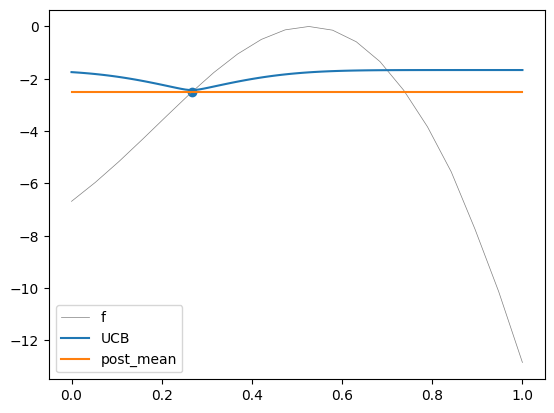

starting iteration 1


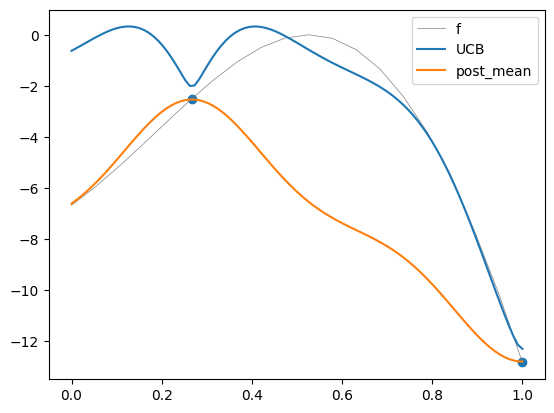

starting iteration 2


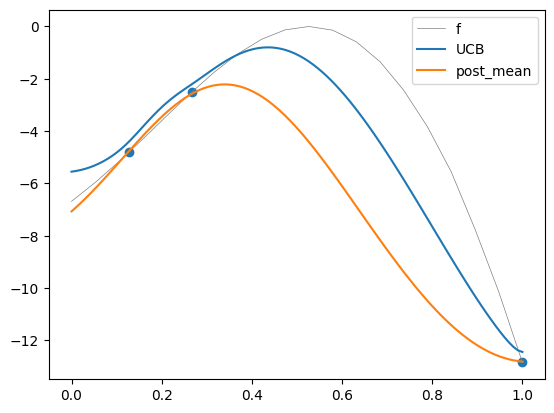

starting iteration 3


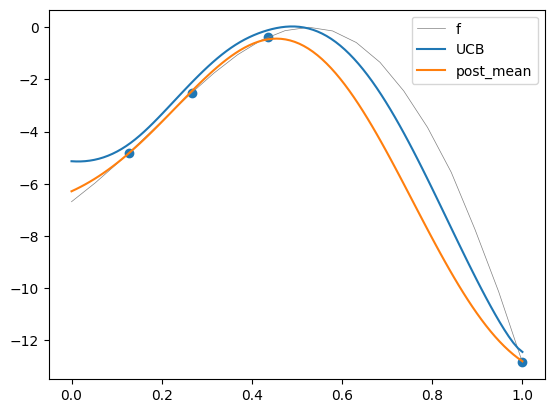

starting iteration 4


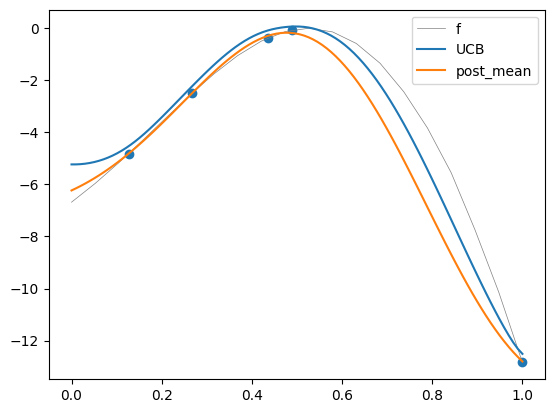

starting iteration 5


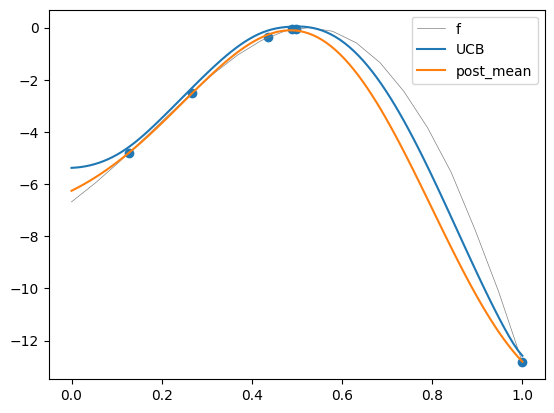

std best obj: tensor([[-0.0403]], dtype=torch.float64)
norm est: tensor([[0.4973]], dtype=torch.float64)
norm true: tensor([0.5263], dtype=torch.float64)
raw est: tensor([[0.5984]], dtype=torch.float64)
raw true: [0.61578947]


In [8]:
NUM_ITER = 5

# init data
n_init = 1


halton_sampler = Halton(d=1, scramble=True)
train_X = halton_sampler.random(n=n_init)
train_X = torch.tensor(train_X, dtype= torch.double)


train_Y = J(train_X)[0]
best_y = train_Y

mll, gp = init_model(train_X, train_Y)
fit_gpytorch_mll(mll)
UCB = UpperConfidenceBound(model=gp,beta=0.7)
plot_iteration(UCB, train_X, train_Y, gp)

for i in range(NUM_ITER):
    print(f"starting iteration {i+1}")

    M = train_Y.max()

    new_x, new_y = optimize_acqf_and_get_observation(UCB)

    if new_y > M:
        best_y = new_y
        best_x = new_x

    train_X = torch.cat([train_X, new_x])
    train_Y = torch.cat([train_Y, new_y])

    mll, gp = init_model(train_X, train_Y)

    fit_gpytorch_mll(mll)

    UCB = UpperConfidenceBound(model=gp,beta=0.7)

    plot_iteration(UCB, train_X, train_Y, gp)


print(f"std best obj: {best_y}")
print(f"norm est: {best_x}")
print(f"norm true: {x}")

print(f"raw est: {best_x * (param_max - param_min) + param_min}")
print(f"raw true: {param.iloc[10].values}")
